In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

MODELS_DIR = '../data/models/predictor'
SPLIT_DIR  = '../data/splits'

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

In [2]:
pipeline_lr  = joblib.load(f'{MODELS_DIR}/logistic_regression.pkl')
pipeline_rf  = joblib.load(f'{MODELS_DIR}/random_forest.pkl')
pipeline_xgb = joblib.load(f'{MODELS_DIR}/xgboost.pkl')

modelos = {
    'Regresión Logística': pipeline_lr,
    'Random Forest':       pipeline_rf,
    'XGBoost':             pipeline_xgb,
}

X_test  = pd.read_csv(f'{SPLIT_DIR}/X_test.csv')
y_test  = pd.read_csv(f'{SPLIT_DIR}/y_test.csv').squeeze()
X_train = pd.read_csv(f'{SPLIT_DIR}/X_train.csv')
y_train = pd.read_csv(f'{SPLIT_DIR}/y_train.csv').squeeze()

print(f'\nDistribución en test:')
print(y_test.value_counts())


Distribución en test:
is_open
1    23921
0     6128
Name: count, dtype: int64


In [38]:
resultados = {}

for nombre, modelo in modelos.items():
    y_pred      = modelo.predict(X_test)
    y_prob      = modelo.predict_proba(X_test)[:, 1]

    resultados[nombre] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'precision_0':  precision_score(y_test, y_pred, pos_label=0),
        'recall_0':     recall_score(y_test, y_pred, pos_label=0),
        'f1_0':         f1_score(y_test, y_pred, pos_label=0),
        'precision_1':  precision_score(y_test, y_pred, pos_label=1),
        'recall_1':     recall_score(y_test, y_pred, pos_label=1),
        'f1_1':         f1_score(y_test, y_pred, pos_label=1),
        'f1_macro':     f1_score(y_test, y_pred, average='macro'),
        'roc_auc':      roc_auc_score(y_test, y_prob),
    }

    print(f' {nombre}')
    print(classification_report(y_test, y_pred, target_names=['Cerrado (0)', 'Abierto (1)']))
    print(f'ROC-AUC: {resultados[nombre]["roc_auc"]:.4f}')


 Regresión Logística
              precision    recall  f1-score   support

 Cerrado (0)       0.36      0.70      0.48      6128
 Abierto (1)       0.90      0.69      0.78     23921

    accuracy                           0.69     30049
   macro avg       0.63      0.69      0.63     30049
weighted avg       0.79      0.69      0.72     30049

ROC-AUC: 0.7611

 Random Forest
              precision    recall  f1-score   support

 Cerrado (0)       0.45      0.59      0.51      6128
 Abierto (1)       0.89      0.81      0.85     23921

    accuracy                           0.77     30049
   macro avg       0.67      0.70      0.68     30049
weighted avg       0.80      0.77      0.78     30049

ROC-AUC: 0.7817

 XGBoost
              precision    recall  f1-score   support

 Cerrado (0)       0.42      0.67      0.52      6128
 Abierto (1)       0.90      0.77      0.83     23921

    accuracy                           0.75     30049
   macro avg       0.66      0.72      0.67     

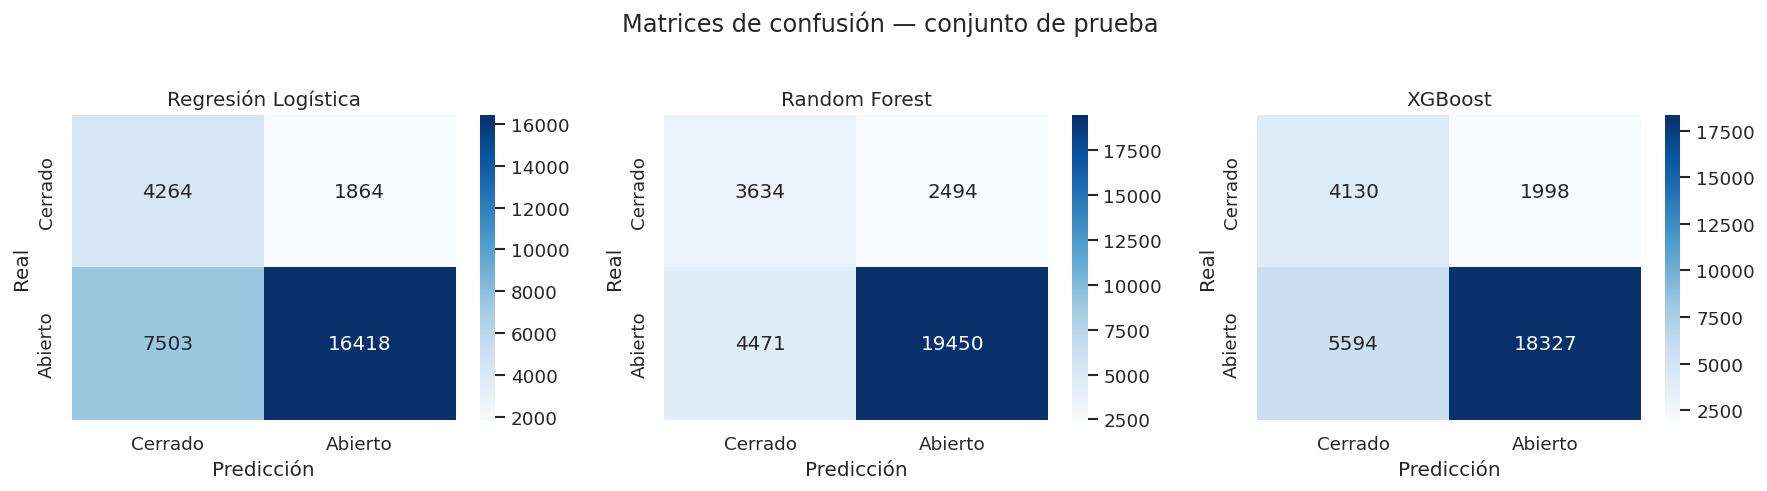

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['Cerrado', 'Abierto'],
        yticklabels=['Cerrado', 'Abierto']
    )
    ax.set_title(nombre)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de confusión', y=1.02)
plt.tight_layout()
plt.show()

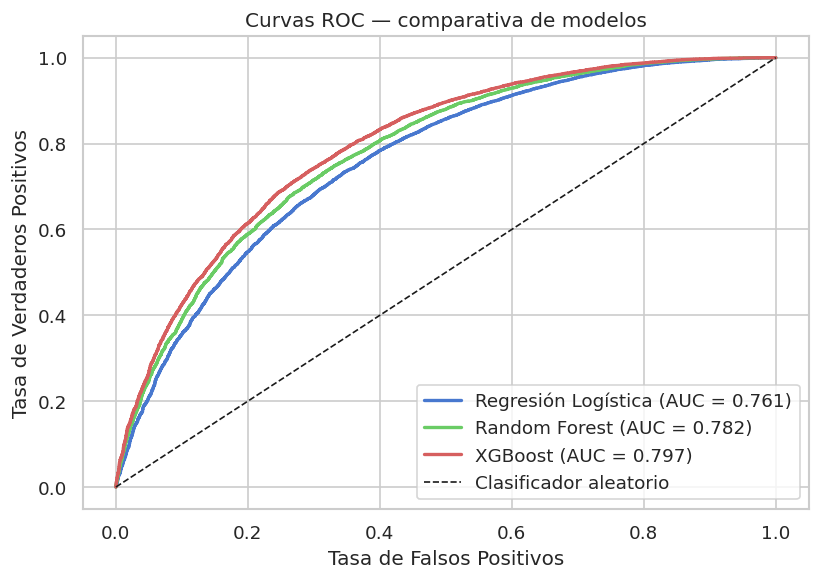

In [40]:
fig, ax = plt.subplots(figsize=(7, 5))

colores = {
    'Regresión Logística': '#4878cf',
    'Random Forest':       '#6acc65',
    'XGBoost':             '#d65f5f',
}

for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['roc_auc']
    ax.plot(
        fpr,
        tpr,
        label=f'{nombre} (AUC = {auc:.3f})',
        color=colores[nombre],
        lw=2
    )

ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

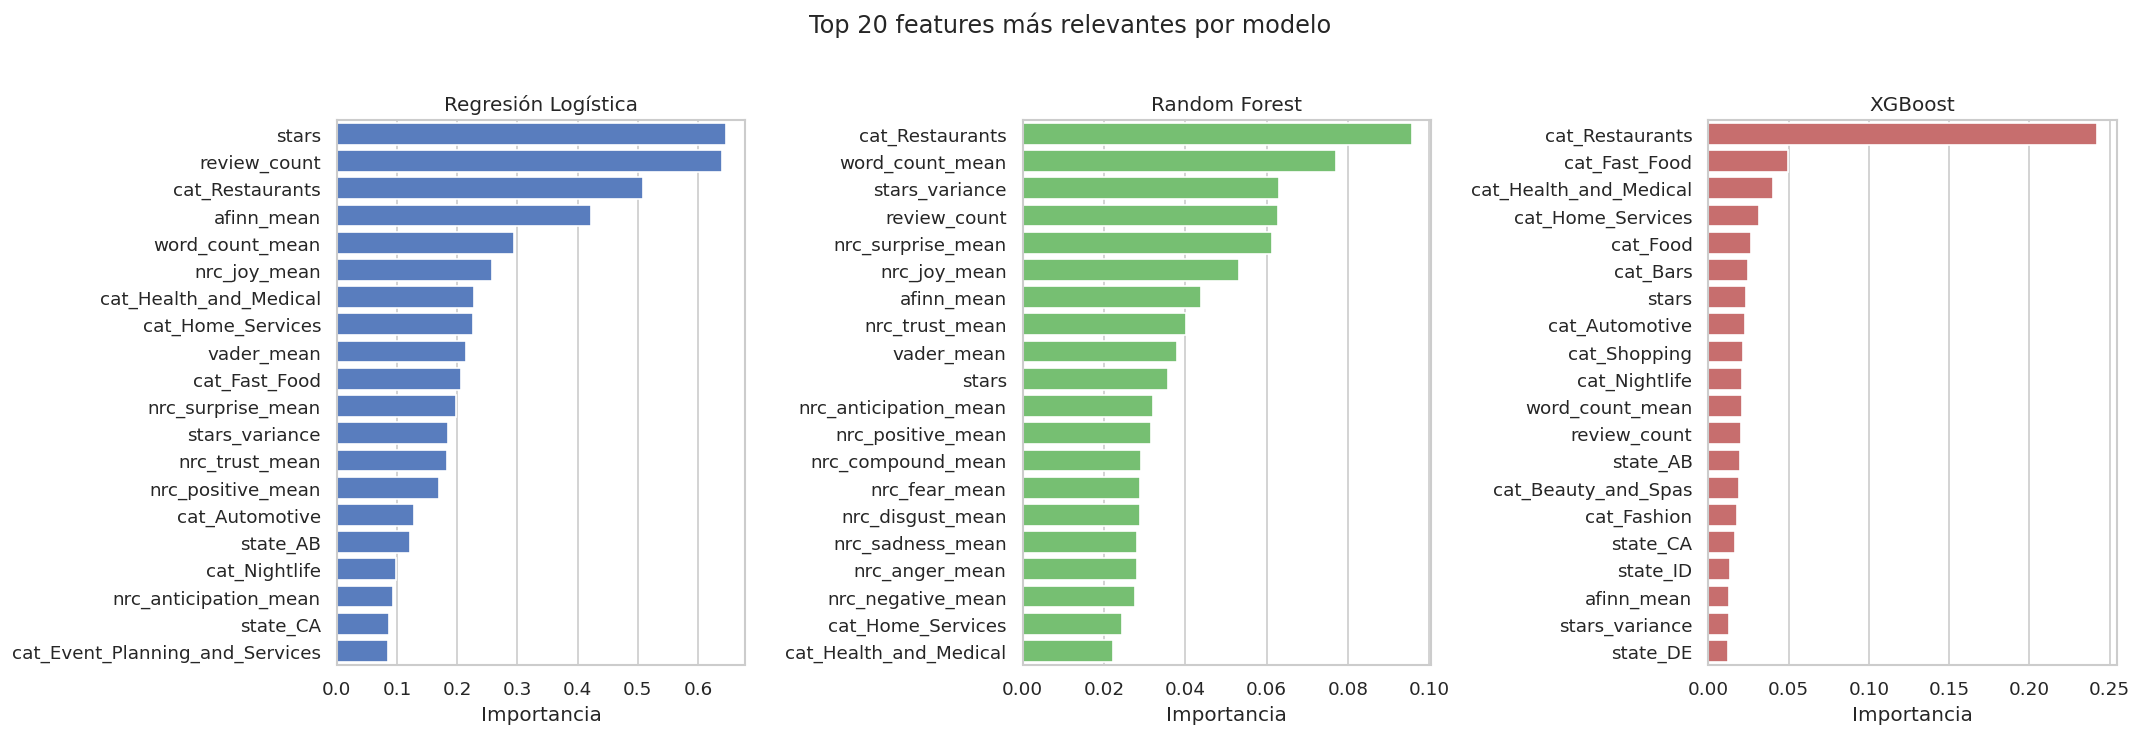

In [3]:
feature_names = X_test.columns.tolist()
TOP_N = 20

importances_rf = pipeline_rf.named_steps['clf'].feature_importances_
df_imp_rf = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances_rf
}).sort_values('importance', ascending=False).head(TOP_N)

importances_xgb = pipeline_xgb.named_steps['clf'].feature_importances_
df_imp_xgb = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances_xgb
}).sort_values('importance', ascending=False).head(TOP_N)

coefs_lr = np.abs(pipeline_lr.named_steps['clf'].coef_[0])
df_imp_lr = pd.DataFrame({
    'feature':    feature_names,
    'importance': coefs_lr
}).sort_values('importance', ascending=False).head(TOP_N)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (df_imp, titulo, color) in zip(axes, [
    (df_imp_lr, 'Regresión Logística', '#4878cf'),
    (df_imp_rf, 'Random Forest', '#6acc65'),
    (df_imp_xgb, 'XGBoost', '#d65f5f'),
]):
    sns.barplot(
        data=df_imp,
        x='importance',
        y='feature',
        ax=ax,
        color=color
    )
    ax.set_title(titulo)
    ax.set_xlabel('Importancia')
    ax.set_ylabel('')

plt.suptitle(f'Top {TOP_N} features más relevantes por modelo', y=1.02)
plt.tight_layout()
plt.show()

In [42]:
df_comparativa = pd.DataFrame({
    nombre: {
        'Precision (cerrado)': round(res['precision_0'], 4),
        'Recall (cerrado)':    round(res['recall_0'],    4),
        'F1 (cerrado)':        round(res['f1_0'],        4),
        'Precision (abierto)': round(res['precision_1'], 4),
        'Recall (abierto)':    round(res['recall_1'],    4),
        'F1 (abierto)':        round(res['f1_1'],        4),
        'F1 Macro':            round(res['f1_macro'],    4),
        'ROC-AUC':             round(res['roc_auc'],     4),
    }
    for nombre, res in resultados.items()
}).T

print(df_comparativa.to_string())

Comparativa de métricas — conjunto de prueba
                     Precision (cerrado)  Recall (cerrado)  F1 (cerrado)  Precision (abierto)  Recall (abierto)  F1 (abierto)  F1 Macro  ROC-AUC
Regresión Logística               0.3624            0.6958        0.4766               0.8980            0.6863        0.7780    0.6273   0.7611
Random Forest                     0.4484            0.5930        0.5106               0.8863            0.8131        0.8481    0.6794   0.7817
XGBoost                           0.4247            0.6740        0.5211               0.9017            0.7661        0.8284    0.6747   0.7970


In [43]:
# Ver si aplicar SMOTE o no debido al desbalanceo

UMBRAL_RECALL = 0.50

print('Evaluación del recall sobre la clase minoritaria (cerrados):')
necesita_smote = []

for nombre, res in resultados.items():
    recall = res['recall_0']
    estado = 'OK' if recall >= UMBRAL_RECALL else 'BAJO — considerar SMOTE'
    print(f'  {nombre:<25} recall(cerrado) = {recall:.4f}  →  {estado}')
    if recall < UMBRAL_RECALL:
        necesita_smote.append(nombre)

if necesita_smote:
    print(f'\n⚠ Modelos con recall bajo: {necesita_smote}')
    print('Se recomienda reentrenar aplicando SMOTE sobre el conjunto de entrenamiento.')
else:
    print('\n✓ Todos los modelos superan el umbral de recall. No es necesario aplicar SMOTE.')

Evaluación del recall sobre la clase minoritaria (cerrados):
  Regresión Logística       recall(cerrado) = 0.6958  →  OK
  Random Forest             recall(cerrado) = 0.5930  →  OK
  XGBoost                   recall(cerrado) = 0.6740  →  OK

✓ Todos los modelos superan el umbral de recall. No es necesario aplicar SMOTE.
